## 6 — MRdeeP Climate
Multivariate Multilevel Regression with Deep Generative Post-Stratification  

Pipeline:
1. `insert_data` — encodes survey + benchmark, builds augmented benchmark proportional to ACS population weights  
2. `fit` — trains an ensemble of CGANs (Wasserstein loss with gradient penalty)  
3. `post_stratify('state_fips')` — generates synthetic micro-data for every demographic cell, groups by state → `happening_bin` estimates extracted

In [1]:
# Install PyTorch (CPU) if needed — MRdeeP uses it as the deep-learning backend
%pip install torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force PyTorch backend (mlx not installed in this env)
import os
os.environ["DEEPVERSE_BACKEND"] = "pytorch"

# Add the MRdeeP package to the path
sys.path.insert(0, "/Users/carmenk/Documents/CSS/Capstone/mrdeep/python")
from mrdeep import MRdeeP

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"

### 1. Load and prepare data

In [3]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                         dtype={"state_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                         dtype={"state_fips": str})

# ── Demographic variables shared between survey and benchmark ─────────────────
DEMOG_VARS = ["gender", "race4", "educ_category", "state_fips"]

OUTCOME_COLS = [c for c in survey_raw.columns if c.endswith("_bin")]
print(f"Survey raw:    {survey_raw.shape}")
print(f"Outcome cols:  {len(OUTCOME_COLS)} binary outcomes")
print(f"Poststrat:     {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey raw:    (1200, 38)
Outcome cols:  30 binary outcomes
Poststrat:     (1632, 9) | 51 states


In [4]:
# ── Survey: keep only rows with no NaN in any outcome, select cols ────────────
survey = (
    survey_raw[DEMOG_VARS + OUTCOME_COLS]
    .dropna()                          # drop any respondent with a DK in any outcome
    .copy()
)
survey["educ_category"] = survey["educ_category"].astype(str)

# ── Benchmark: add population-proportional count column ──────────────────────
# Normalize N_rounded so the augmented benchmark totals ~16,320 rows (10× strata)
# This preserves relative cell sizes so post_stratify() is population-weighted.
benchmark = ps_frame[DEMOG_VARS + ["N_rounded"]].copy()
benchmark["educ_category"] = benchmark["educ_category"].astype(str)
target_rows = len(benchmark) * 10          # ~16,320 total rows with oversample=1
benchmark["count"] = np.maximum(
    1,
    (benchmark["N_rounded"] / benchmark["N_rounded"].sum() * target_rows).round()
).astype(int)
benchmark = benchmark.drop(columns=["N_rounded"])

print(f"Survey (complete cases): {len(survey):,}  "
      f"({survey['happening_bin'].mean()*100:.1f}% believe GW is happening)")
print(f"Benchmark: {len(benchmark)} strata | count range [{benchmark['count'].min()}, {benchmark['count'].max()}]")
print(f"Augmented benchmark rows (oversample=1): {benchmark['count'].sum():,}")

Survey (complete cases): 27  (66.7% believe GW is happening)
Benchmark: 1632 strata | count range [1, 159]
Augmented benchmark rows (oversample=1): 16,559


### 2. Insert data into MRdeeP

In [5]:
mod = MRdeeP(ensembles=3, random_state=42)

mod.insert_data(
    survey    = survey,
    benchmark = benchmark,
    demog_vars = DEMOG_VARS,
    count_col  = "count",
    oversample = 1,     # augmented benchmark already sized; no further multiplication
)
print(mod)

MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 27 obs, 30 substantive vars, 4 demographic vars
  Augmented benchmark: 16559 rows
  Fitted: False


### 3. Train CGAN ensemble
Default architecture: 4 × 256-neuron hidden layers, Wasserstein loss + gradient penalty.  
`patience=50` stops early if validation generator loss stops improving.

In [6]:
mod.fit(
    epochs       = 500,
    patience     = 50,
    batch_size   = 256,
    k            = 32,
    print_runtime = True,
)
print(mod)

Ensemble 1/3
Ensemble 2/3
Ensemble 3/3
Total fit time: 29.4 seconds.
MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 27 obs, 30 substantive vars, 4 demographic vars
  Augmented benchmark: 16559 rows
  Fitted: True
    Noise dim (k): 32
    Ensemble members: 3
    Generated survey: 16559 rows
    Total fit time: 29.4s


### 4. Post-stratify → state-level estimates for all 30 outcomes

In [7]:
estimates = mod.post_stratify(levels="state_fips")

print(f"Estimates shape: {estimates.shape}  "
      f"({estimates['state_fips'].nunique()} states × {len(OUTCOME_COLS)} outcomes)")
estimates[["state_fips", "happening_bin"]].head(10)

Estimates shape: (51, 31)  (51 states × 30 outcomes)


,state_fips,happening_bin
0,01,0.445249
1,02,0.462443
2,04,0.443404
3,05,0.448346
4,06,0.449400
5,08,0.438129
6,09,0.455691
7,10,0.454532
8,11,0.451698
9,12,0.455821


### 5. Extract `happening_bin` and add state names

In [8]:
STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}

result = estimates[["state_fips", "happening_bin"]].rename(
    columns={"happening_bin": "happening_estimate"}
)
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National mean estimate: {result['happening_estimate'].mean():.3f}")
print("\nTop 10:"); print(result.head(10).to_string(index=False))
print("\nBottom 10:"); print(result.tail(10).to_string(index=False))

National mean estimate: 0.455

Top 10:
state_fips  happening_estimate    state_name
        39            0.478005          Ohio
        54            0.470451 West Virginia
        36            0.467037      New York
        21            0.466709      Kentucky
        53            0.465027    Washington
        32            0.464072        Nevada
        51            0.463033      Virginia
        02            0.462443        Alaska
        23            0.462409         Maine
        40            0.461417      Oklahoma

Bottom 10:
state_fips  happening_estimate     state_name
        25            0.447013  Massachusetts
        55            0.446668      Wisconsin
        37            0.446427 North Carolina
        48            0.445972          Texas
        18            0.445785        Indiana
        01            0.445249        Alabama
        56            0.445145        Wyoming
        04            0.443404        Arizona
        20            0.442251         K

### 6. Visualise

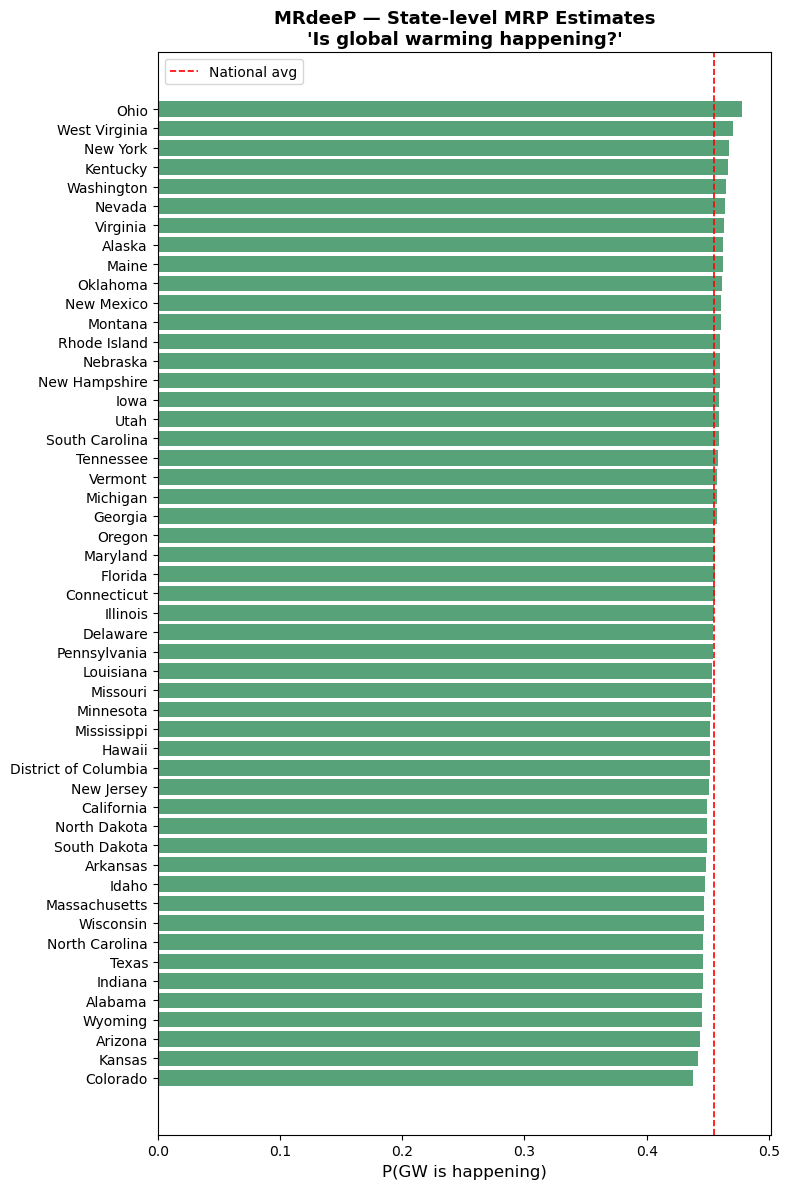

In [9]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="seagreen", alpha=0.8)
ax.axvline(result["happening_estimate"].mean(), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("MRdeeP — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 7. Save results

In [10]:
OUT = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv"
result[["state_fips", "state_name", "happening_estimate"]].rename(columns={"happening_estimate":"estimate"}).to_csv(OUT, index=False)
print(f"Saved → {OUT}")
print(result[["state_fips", "state_name", "happening_estimate"]].to_string(index=False))

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv
state_fips           state_name  happening_estimate
        39                 Ohio            0.478005
        54        West Virginia            0.470451
        36             New York            0.467037
        21             Kentucky            0.466709
        53           Washington            0.465027
        32               Nevada            0.464072
        51             Virginia            0.463033
        02               Alaska            0.462443
        23                Maine            0.462409
        40             Oklahoma            0.461417
        35           New Mexico            0.460584
        30              Montana            0.460479
        44         Rhode Island            0.460286
        31             Nebraska            0.460276
        33        New Hampshire            0.459878
        19                 Iowa            0.459537
      